In [ ]:
!pip install -U bitsandbytes 

In [1]:
import os
import sys

try:
    sys.path.append("/kaggle/input")
    from qnlicomplete import utils
except:
    path = os.getcwd()
    while True:
        if 'utils.py' in os.listdir(path):
            if path not in sys.path:
                sys.path.append(path)
            break
        new_path = os.path.dirname(path)
        if new_path == path:
            from qnlicomplete import utils
            break
        path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'qnli',
                'quantization': '4bit',
                'training_mode': 'few shot 2 examples',
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /kaggle/working/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
utils.hf_login("HF_TOKEN")

In [4]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer and change padding side
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [5]:
# Lock 2 examples to be used for few shot

qnli_val = pd.read_csv('/kaggle/input/qnlicomplete/qnli_val.csv')

qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

demo_idxs = np.load('/kaggle/input/qnlicomplete/qnli_few_shot_example_idx.npy')

k = 2 # Examples to lock
demo_examples = qnli_val.iloc[demo_idxs[:k]]
qnli_val_few_shot = qnli_val.drop(qnli_val.index[demo_idxs])

In [6]:
demo_examples

,question,sentence,label,idx
2227,Which of his future general's fathers helped T...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,2227
1824,Which well-known general abandoned Jamukha's c...,Jamukha's assumption of this title was the fin...,not entailment,1824


In [7]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nQuestion: {demo_examples.iloc[i]['question']}\nSentence: {demo_examples.iloc[i]['sentence']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Question: Which of his future general's fathers helped Temüjin escape the Tayichi'ud?
Sentence: The Tayichi'ud enslaved Temüjin (reportedly with a cangue, a sort of portable stocks), but with the help of a sympathetic guard, the father of Chilaun (who later became a general of Genghis Khan), he was able to escape from the ger (yurt) in the middle of the night by hiding in a river crevice.[citation needed]
Answer: entailment 

Example 2
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 




In [ ]:
qnli_val_few_shot.info()

In [ ]:
qnli_val_few_shot.head()

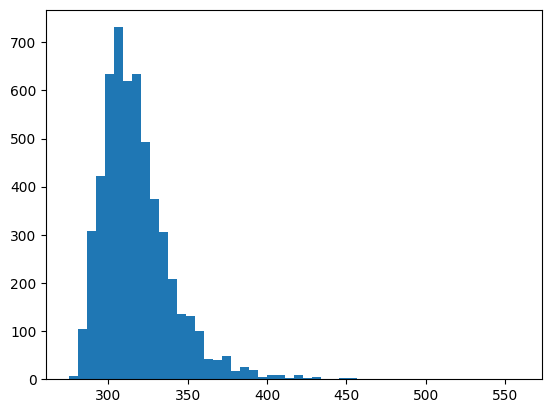

Max prompt length: 559
Max label length: 4


In [8]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(qnli_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [15]:
prompt_lengths, _ = utils.get_lengths(qnli_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 450 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 450 tokens and will be truncated: 4 out of 5448 examples or 0.073%


Since we have only 2 example that goes over a length of 200, we are going to use 200 as the default for `max_length` to truncate some prompts in order to offload computing.

In [16]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=qnli_val,
                                        examples=prompt_examples,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=450,
                               label_max_length=3)

batch_size = 25 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False) 

In [17]:
# Show an example prompt
print(dataset_test[0]['prompt'])

Examples:
Example 1
Question: Which of his future general's fathers helped Temüjin escape the Tayichi'ud?
Sentence: The Tayichi'ud enslaved Temüjin (reportedly with a cangue, a sort of portable stocks), but with the help of a sympathetic guard, the father of Chilaun (who later became a general of Genghis Khan), he was able to escape from the ger (yurt) in the middle of the night by hiding in a river crevice.[citation needed]
Answer: entailment 

Example 2
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 

 
Given the above examples as reference does the sentence entail the question in the following case? Answer exactly one word in lowercase as in the examples: 'not entailment' or 'entailment'. 
sentence: As of that day, the new constitution heralding the Second Republic came into force. 
question:

In [18]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)


            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   0%|          | 1/219 [01:10<4:14:56, 70.17s/batch]

Checkpoint saved: 1, /kaggle/working/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt


Evaluating:  23%|██▎       | 51/219 [1:03:50<3:30:27, 75.16s/batch]

Checkpoint saved: 51, /kaggle/working/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt


Evaluating:  46%|████▌     | 101/219 [2:06:32<2:27:57, 75.23s/batch]

Checkpoint saved: 101, /kaggle/working/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt


Evaluating:  51%|█████     | 112/219 [2:20:18<2:13:56, 75.11s/batch]

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Few-Shot/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Few-Shot/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Few-Shot/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Few-Shot/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_3_exampl

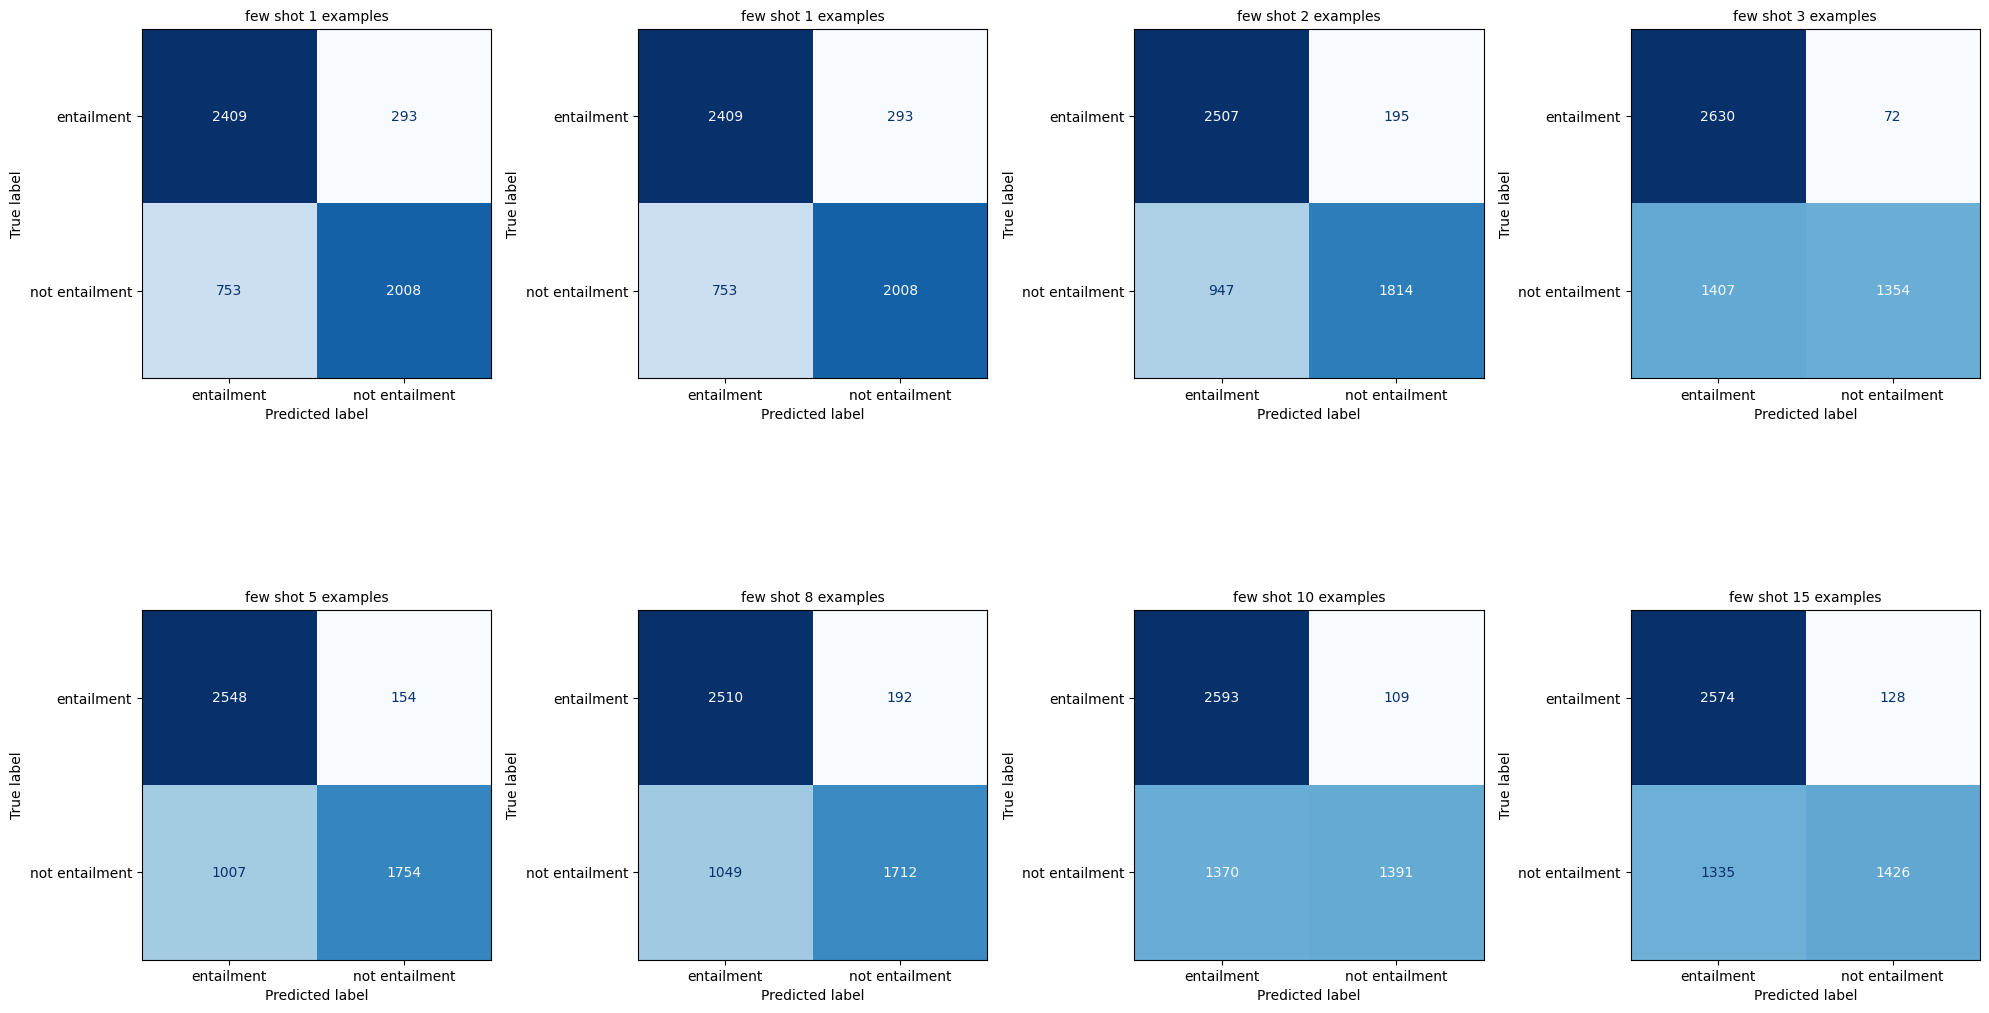

In [4]:
import matplotlib.pyplot as plt

examples_no = [1, 2, 3, 5, 8, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for k in examples_no:
    global_params = {'dataset_type': 'qnli',
                    'quantization': '4bit',
                    'training_mode': f'few shot {k} examples',
                    'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1

    if k == 1:
        global_params = {'dataset_type': 'qnli',
                        'quantization': '4bit',
                        'training_mode': f'few shot {k} examples',
                        'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

        checkpoint_path = utils.create_checkpoint_path(params=global_params)
        predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

        acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                                predicted_labels=predicted_labels,
                                                gold_labels=gold_labels,
                                                params=global_params,
                                                ax=axes[idx]
                                                )   
        accs.append(round(acc, 4))
        precisions.append(round(precision, 4))
        recalls.append(round(recall, 4))
        f1s.append(round(f1, 4))
        mccs.append(round(mcc, 4))
        kappas.append(round(kappa, 4))

        idx += 1


plt.tight_layout()
plt.show()

In [6]:
idx = [f"{k} examples" for k in examples_no]
idx.append("1 examples opposite")

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= idx
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 examples,0.8085,0.8173,0.8094,0.8075,0.6266,0.6177
2 examples,0.8085,0.8173,0.8094,0.8075,0.6266,0.6177
3 examples,0.7910,0.8144,0.7924,0.7875,0.6064,0.5831
5 examples,0.7293,0.8005,0.7319,0.7136,0.5279,0.4613
8 examples,0.7875,0.8180,0.7891,0.7829,0.6065,0.5763
10 examples,0.7728,0.8022,0.7745,0.7679,0.5760,0.5472
15 examples,0.7293,0.7908,0.7317,0.7155,0.5192,0.4612
1 examples opposite,0.7322,0.7881,0.7346,0.7198,0.5199,0.4669


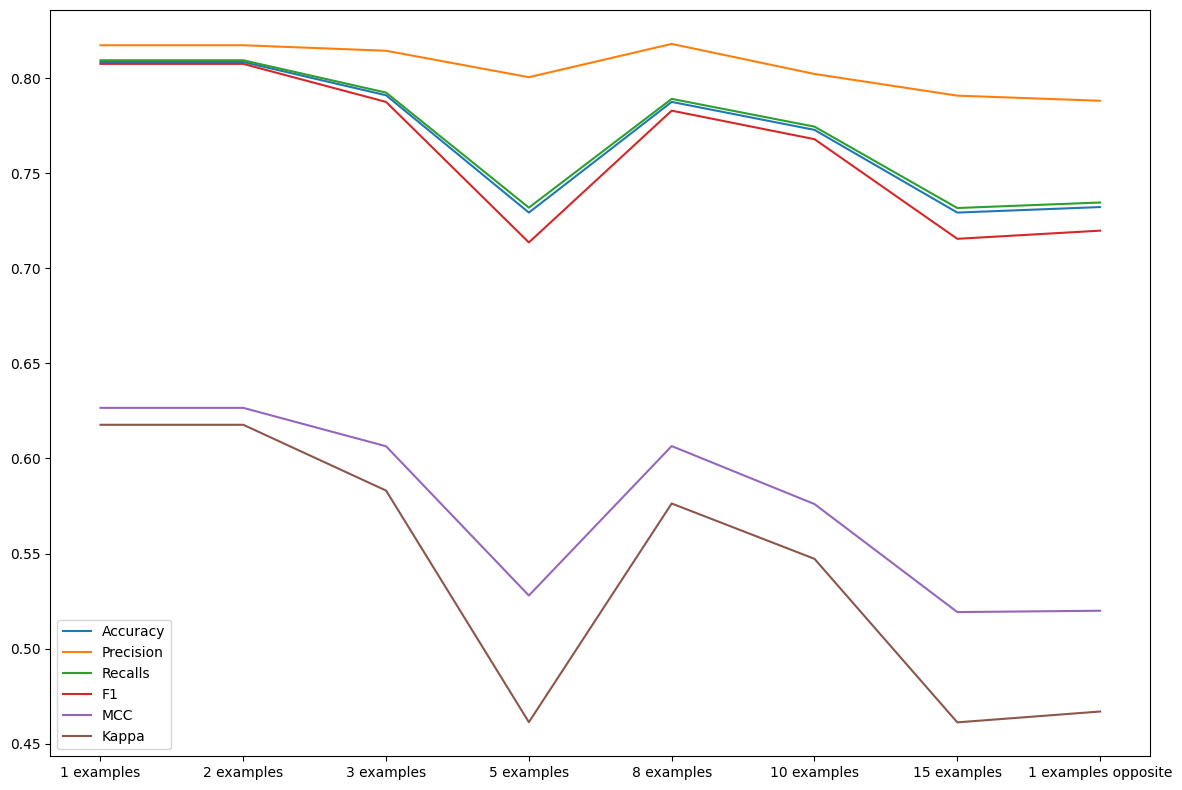

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
metrics_df.plot(kind='line', ax=ax)
plt.tight_layout()
plt.show()